# Disparidades socioeconómicas y convergencia regional en el Perú: un análisis de heterogeneidad espacial, 2007–2019

**Autora:** Karen Aymé Medrano Valenzuela  
**Curso:** EC-585 Economía Urbana y Regional  
**Unidad de análisis:** 24 departamentos del Perú  
**Periodo principal:** 2007–2019

Este cuaderno reproduce y adapta la estrategia empírica de Duran et al. (2024) al caso peruano. El flujo de trabajo comprende: construcción de variables, estadística descriptiva, análisis exploratorio espacial, pruebas LM, modelos de error espacial, regresión geográficamente ponderada y ajustes no paramétricos.

> **Adaptación metodológica.** El artículo de referencia normaliza su índice de desarrollo mediante min–max. En este trabajo se utiliza directamente el IDH del PNUD porque ya está expresado entre 0 y 1. Por ello, la aplicación es una réplica metodológica adaptada y no una reproducción exacta de la variable original.

## 0. Configuración del entorno

La primera ejecución puede tardar entre **8 y 20 minutos**, esto es por los paquetes espaciales.

**Antes de ejecutar:** en Colab seleccione `Entorno de ejecución → Cambiar tipo de entorno de ejecución → R`.

### 0.1 Verificación del kernel y dependencias del sistema

In [4]:
cat("Versión de R:", R.version.string, "\n")
cat("Sistema:", Sys.info()[["sysname"]], Sys.info()[["release"]], "\n")

# Dependencias de sistema necesarias si algún paquete espacial debe compilarse.
if (Sys.info()[["sysname"]] == "Linux") {
  cat("Actualizando el índice de paquetes del sistema...\n")
  system("apt-get update -qq")
  cat("Instalando bibliotecas geoespaciales del sistema...\n")
  system(paste(
    "DEBIAN_FRONTEND=noninteractive apt-get install -y -qq",
    "libudunits2-dev libgdal-dev libgeos-dev libproj-dev",
    "libssl-dev libcurl4-openssl-dev libxml2-dev"
  ))
}
cat("Dependencias del sistema listas.\n")

Versión de R: R version 4.6.0 (2026-04-24) 
Sistema: Linux 6.6.122+ 
Actualizando el índice de paquetes del sistema...
Instalando bibliotecas geoespaciales del sistema...
Dependencias del sistema listas.


### 0.2 Instalación visible de paquetes de R

In [5]:
options(timeout = 1200)

# Intalamos Posit Package Manager suele proporcionar binarios para Linux y acelera la instalación.
codename <- tryCatch(
  system("bash -lc 'source /etc/os-release && echo $VERSION_CODENAME'", intern = TRUE),
  error = function(e) "jammy"
)
if (length(codename) == 0 || codename == "") codename <- "jammy"
repo_binario <- paste0(
  "https://packagemanager.posit.co/cran/__linux__/",
  codename,
  "/latest"
)
options(repos = c(CRAN = repo_binario))

paquetes_cran <- c(
  "readxl", "dplyr", "tidyr", "purrr", "stringr",
  "sf", "sp", "spdep", "spatialreg", "spgwr",
  "ggplot2", "patchwork", "moments", "tseries",
  "broom", "knitr", "IRdisplay"
)

instalar_paquete <- function(paquete) {
  if (requireNamespace(paquete, quietly = TRUE)) {
    cat(sprintf("[OK] %-12s ya estaba disponible.\n", paquete))
    return(invisible(TRUE))
  }

  cat(sprintf("[INSTALANDO] %s ...\n", paquete))
  flush.console()
  suppressWarnings(
    try(
      install.packages(
        paquete,
        dependencies = NA,
        Ncpus = 2,
        quiet = TRUE
      ),
      silent = TRUE
    )
  )

  # Respaldo con CRAN estándar si el binario no estuvo disponible.
  if (!requireNamespace(paquete, quietly = TRUE)) {
    cat(sprintf("[REINTENTO CRAN] %s ...\n", paquete))
    options(repos = c(CRAN = "https://cloud.r-project.org"))
    install.packages(paquete, dependencies = NA, Ncpus = 2)
    options(repos = c(CRAN = repo_binario))
  }

  if (!requireNamespace(paquete, quietly = TRUE)) {
    stop(paste("No fue posible instalar el paquete", paquete))
  }
  cat(sprintf("[LISTO] %-12s\n", paquete))
}

for (p in paquetes_cran) instalar_paquete(p)
cat("Todos los paquetes requeridos están disponibles.\n")

[OK] readxl       ya estaba disponible.
[OK] dplyr        ya estaba disponible.
[OK] tidyr        ya estaba disponible.
[OK] purrr        ya estaba disponible.
[OK] stringr      ya estaba disponible.
[OK] sf           ya estaba disponible.
[OK] sp           ya estaba disponible.
[OK] spdep        ya estaba disponible.
[OK] spatialreg   ya estaba disponible.
[OK] spgwr        ya estaba disponible.
[OK] ggplot2      ya estaba disponible.
[OK] patchwork    ya estaba disponible.
[OK] moments      ya estaba disponible.
[OK] tseries      ya estaba disponible.
[OK] broom        ya estaba disponible.
[OK] knitr        ya estaba disponible.
[OK] IRdisplay    ya estaba disponible.
Todos los paquetes requeridos están disponibles.


### 0.3 Carga de paquetes, carpetas y funciones auxiliares

In [6]:
suppressPackageStartupMessages(
  invisible(lapply(paquetes_cran, library, character.only = TRUE))
)

options(
  scipen = 999,
  dplyr.summarise.inform = FALSE,
  warn = 1
)

for (carpeta in c("data", "data/processed", "figures", "tables")) {
  dir.create(carpeta, recursive = TRUE, showWarnings = FALSE)
}

render_md <- function(texto) {
  if (requireNamespace("IRdisplay", quietly = TRUE)) {
    IRdisplay::display_markdown(texto)
  } else {
    cat(texto, "\n")
  }
}

fmt <- function(x, d = 4) {
  formatC(x, format = "f", digits = d, decimal.mark = ".")
}

significancia <- function(p) {
  ifelse(p < 0.01, "estadísticamente significativo al 1%",
    ifelse(p < 0.05, "estadísticamente significativo al 5%",
      ifelse(p < 0.10, "significativo al 10%", "no significativo al 10%")
    )
  )
}

cat("Entorno configurado correctamente.\n")

Entorno configurado correctamente.


## 1. Descarga y preparación de las fuentes

La base integra tres fuentes oficiales: cuentas departamentales y población del INEI, e IDH del PNUD. Los límites administrativos se utilizan únicamente para la construcción de las matrices espaciales y los mapas.

### 1.1 Producto bruto interno departamental

In [7]:
repo_base <- "https://raw.githubusercontent.com/karenmedrano2026/replica-convergencia-peru-ec585/main/data/raw/"
url_pbi <- paste0(repo_base, "PBI%20departamental/")

sufijos <- ifelse(1:24 %in% c(12, 15, 24), "18", "17")
archivos_pbi <- sprintf("pbi_dep%02d_%s.xlsx", 1:24, sufijos)

descargar_seguro <- function(url, destino, intentos = 5) {
  for (i in seq_len(intentos)) {
    ok <- tryCatch({
      download.file(url, destino, mode = "wb", quiet = TRUE)
      file.exists(destino) && file.size(destino) > 1000
    }, error = function(e) FALSE)
    if (ok) return(TRUE)
    Sys.sleep(5 * i)
  }
  FALSE
}

extraer_pbi_departamento <- function(nombre_archivo) {
  destino <- tempfile(fileext = ".xlsx")
  url <- paste0(url_pbi, nombre_archivo)

  if (!descargar_seguro(url, destino)) {
    warning("No se pudo descargar: ", nombre_archivo)
    return(NULL)
  }

  hoja <- read_excel(destino, sheet = "cuadro1", col_names = FALSE)
  nombre_dpto <- trimws(sub(":.*", "", hoja[[2, 1]]))
  anios <- suppressWarnings(as.numeric(hoja[7, -1]))
  actividades <- sapply(hoja[9:19, -1], function(x) suppressWarnings(as.numeric(x)))

  data.frame(
    departamento = nombre_dpto,
    anio = anios,
    pbi_real = colSums(actividades, na.rm = TRUE)
  )
}

panel_pbi_completo <- map_dfr(archivos_pbi, function(archivo) {
  Sys.sleep(1)
  extraer_pbi_departamento(archivo)
}) |>
  filter(!is.na(departamento), !is.na(anio)) |>
  distinct(departamento, anio, .keep_all = TRUE)

stopifnot(n_distinct(panel_pbi_completo$departamento) >= 24)
panel_pbi_completo |> filter(anio %in% c(2007, 2019)) |> count(anio)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `.

anio,n
<dbl>,<int>
2007,24
2019,24


### 1.2 Población departamental

In [8]:
url_pob <- paste0(repo_base, URLencode("población/proy_03_4.xlsx", reserved = FALSE))
destino_pob <- tempfile(fileext = ".xlsx")

if (!descargar_seguro(url_pob, destino_pob)) {
  stop("No fue posible descargar la base de población.")
}

extraer_poblacion_anio <- function(destino, hoja, anio_objetivo) {
  datos <- read_excel(destino, sheet = hoja, col_names = FALSE)
  fila_anios <- as.character(unlist(datos[3, ]))
  col_total <- which(fila_anios == as.character(anio_objetivo))[1]

  if (is.na(col_total)) stop("No se encontró el año ", anio_objetivo, " en la hoja ", hoja)

  filas <- datos[6:nrow(datos), ]
  df <- data.frame(
    ubigeo = as.character(unlist(filas[[1]])),
    departamento = as.character(unlist(filas[[2]])),
    poblacion = suppressWarnings(as.numeric(unlist(filas[, col_total]))),
    anio = anio_objetivo
  )

  df |>
    filter(
      !is.na(ubigeo),
      nchar(ubigeo) == 6,
      substr(ubigeo, 3, 6) == "0000",
      ubigeo != "000000"
    )
}

panel_poblacion <- bind_rows(
  extraer_poblacion_anio(destino_pob, "2006-2008", 2007),
  extraer_poblacion_anio(destino_pob, "2018-2020", 2019)
)

stopifnot(n_distinct(panel_poblacion$departamento) >= 24)
panel_poblacion |> count(anio)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`


anio,n
<dbl>,<int>
2007,25
2019,25


### 1.3 Índice de Desarrollo Humano departamental

In [9]:
url_idh <- paste0(repo_base, "idh/IDH-y-Componentes-2003-2019.xlsx")
destino_idh <- tempfile(fileext = ".xlsx")

if (!descargar_seguro(url_idh, destino_idh)) {
  stop("No fue posible descargar la base de IDH.")
}

extraer_idh_2007 <- function(destino) {
  datos <- read_excel(destino, sheet = "Variables del IDH 2003-2017", col_names = FALSE)
  fila_anios <- as.character(unlist(datos[5, ]))
  candidatas <- which(fila_anios == "2007" & seq_along(fila_anios) >= 14)
  col_idh <- candidatas[1]

  if (is.na(col_idh)) stop("No se localizó la columna del IDH 2007.")

  filas <- datos[8:nrow(datos), ]
  data.frame(
    ubigeo = as.character(unlist(filas[[1]])),
    departamento = as.character(unlist(filas[[2]])),
    idh = suppressWarnings(as.numeric(unlist(filas[, col_idh]))),
    anio = 2007
  ) |>
    filter(
      !is.na(ubigeo),
      nchar(ubigeo) == 6,
      substr(ubigeo, 3, 6) == "0000",
      ubigeo != "000000"
    )
}

extraer_idh_2019 <- function(destino) {
  datos <- read_excel(destino, sheet = "IDH 2019", col_names = FALSE)
  filas <- datos[8:nrow(datos), ]

  data.frame(
    ubigeo = as.character(unlist(filas[[1]])),
    departamento = as.character(unlist(filas[[2]])),
    idh = suppressWarnings(as.numeric(unlist(filas[, 17]))),
    anio = 2019
  ) |>
    filter(
      !is.na(ubigeo),
      nchar(ubigeo) == 6,
      substr(ubigeo, 3, 6) == "0000",
      ubigeo != "000000"
    )
}

panel_idh <- bind_rows(
  extraer_idh_2007(destino_idh),
  extraer_idh_2019(destino_idh)
)

stopifnot(n_distinct(panel_idh$departamento) >= 24)
panel_idh |> count(anio)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• ``

anio,n
<dbl>,<int>
2007,24
2019,24


### 1.4 Límites departamentales

In [10]:
url_zip <- paste0(repo_base, "DEPARTAMENTOS_LIMITES.zip")
destino_zip <- tempfile(fileext = ".zip")

if (!descargar_seguro(url_zip, destino_zip)) {
  stop("No fue posible descargar el archivo geográfico.")
}

dir.create("shp_temp", showWarnings = FALSE)
unzip(destino_zip, exdir = "shp_temp", overwrite = TRUE)

peru_shp <- st_read("shp_temp/DEPARTAMENTOS.shp", quiet = TRUE)
stopifnot(nrow(peru_shp) >= 25)

cat("CRS original:", st_crs(peru_shp)$input, "\n")

CRS original: WGS 84 


## 2. Construcción de la base analítica

### 2.1 Definición de variables

Para el desarrollo humano se emplea:

$$
dev_{i,t}=IDH_{i,t}
$$

$$
\Delta dev_i=IDH_{i,2019}-IDH_{i,2007}
$$

El ingreso departamental se expresa en términos relativos respecto del promedio nacional:

$$
\ln(rgdpc_{i,t})=
\ln\left(
\frac{PBIpc_{i,t}}
{\overline{PBIpc_t}}
\right)
$$

$$
\Delta \ln(rgdpc_i)=
\ln(rgdpc_{i,2019})-
\ln(rgdpc_{i,2007})
$$

La relativización permite comparar la posición económica de cada departamento con el promedio transversal de cada año y reduce la influencia de la unidad monetaria.

In [11]:
normalizar_depto <- function(x) {
  x <- toupper(trimws(x))
  x <- chartr("ÁÉÍÓÚÜÑ", "AEIOUUN", x)
  x <- gsub("PROV\\. CONST\\. DEL CALLAO", "CALLAO", x)
  x
}

panel_pbi_completo <- panel_pbi_completo |>
  mutate(clave = normalizar_depto(departamento)) |>
  distinct(clave, anio, .keep_all = TRUE)

panel_poblacion <- panel_poblacion |>
  mutate(clave = normalizar_depto(departamento)) |>
  distinct(clave, anio, .keep_all = TRUE)

panel_idh <- panel_idh |>
  mutate(clave = normalizar_depto(departamento)) |>
  distinct(clave, anio, .keep_all = TRUE)

peru_shp <- peru_shp |>
  mutate(clave = normalizar_depto(DEPARTAMEN))

pbi_wide <- panel_pbi_completo |>
  filter(anio %in% c(2007, 2019)) |>
  select(clave, anio, pbi_real) |>
  pivot_wider(names_from = anio, values_from = pbi_real, names_prefix = "pbi_")

pob_wide <- panel_poblacion |>
  filter(anio %in% c(2007, 2019)) |>
  select(clave, anio, poblacion) |>
  pivot_wider(names_from = anio, values_from = poblacion, names_prefix = "pob_")

idh_wide <- panel_idh |>
  filter(anio %in% c(2007, 2019)) |>
  select(clave, anio, idh) |>
  pivot_wider(names_from = anio, values_from = idh, names_prefix = "idh_")

panel_final <- pbi_wide |>
  inner_join(pob_wide, by = "clave") |>
  inner_join(idh_wide, by = "clave") |>
  mutate(
    pbipc_2007 = pbi_2007 / pob_2007,
    pbipc_2019 = pbi_2019 / pob_2019,
    ln_rgdpc_2007 = log(pbipc_2007 / mean(pbipc_2007, na.rm = TRUE)),
    ln_rgdpc_2019 = log(pbipc_2019 / mean(pbipc_2019, na.rm = TRUE)),
    d_rgdpc = ln_rgdpc_2019 - ln_rgdpc_2007,
    d_dev = idh_2019 - idh_2007
  ) |>
  arrange(clave)

stopifnot(nrow(panel_final) == 24)
stopifnot(!anyNA(panel_final))

write.csv(panel_final, "data/processed/panel_final_convergencia.csv", row.names = FALSE)
panel_final |> select(clave, idh_2007, idh_2019, d_dev, ln_rgdpc_2007, ln_rgdpc_2019, d_rgdpc)

clave,idh_2007,idh_2019,d_dev,ln_rgdpc_2007,ln_rgdpc_2019,d_rgdpc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AMAZONAS,0.2811134,0.4177358,0.1366224,-0.8836960,-0.6466771,0.23701895
ANCASH,0.3449439,0.5159339,0.1709900,0.3037613,0.1836524,-0.12010889
APURIMAC,0.2859855,0.4109258,0.1249403,-0.9230976,0.1564683,1.07956593
AREQUIPA,0.4534196,0.6425453,0.1891257,0.3106520,0.4069031,0.09625107
AYACUCHO,0.2701486,0.4327412,0.1625925,-0.8277129,-0.4694254,0.35828753
CAJAMARCA,0.2831088,0.4251182,0.1420093,-0.6241554,-0.5879579,0.03619750
CUSCO,0.3141304,0.5120717,0.1979412,-0.1608202,0.1399095,0.30072968
HUANCAVELICA,0.2147282,0.3838253,0.1690971,-0.6805838,-0.4069045,0.27367929
HUANUCO,0.2720315,0.4536516,0.1816201,-0.9515014,-0.5785533,0.37294808


In [12]:
control_base <- panel_final |>
  summarise(
    departamentos = n(),
    faltantes_idh_2007 = sum(is.na(idh_2007)),
    faltantes_idh_2019 = sum(is.na(idh_2019)),
    faltantes_pbi_2007 = sum(is.na(ln_rgdpc_2007)),
    faltantes_pbi_2019 = sum(is.na(ln_rgdpc_2019))
  )

knitr::kable(
  control_base,
  digits = 0,
  caption = "Tabla 1. Control de integridad de la base analítica"
)



Table: Tabla 1. Control de integridad de la base analítica

| departamentos| faltantes_idh_2007| faltantes_idh_2019| faltantes_pbi_2007| faltantes_pbi_2019|
|-------------:|------------------:|------------------:|------------------:|------------------:|
|            24|                  0|                  0|                  0|                  0|

**Nota.** Callao no se incorpora como unidad independiente para conservar una base homogénea de 24 departamentos. La exclusión debe indicarse tanto en la metodología como en las limitaciones.

## 3. Geometría y matrices de pesos espaciales

La especificación principal corresponde a una matriz de banda de distancia con ponderación inversa:

$$
w_{ij}=
\begin{cases}
\dfrac{1}{d_{ij}}, & 0<d_{ij}\leq d_0, \\
0, & d_{ij}>d_0.
\end{cases}
$$

donde $d_{ij}$ representa la distancia entre los centroides de los departamentos $i$ y $j$, mientras que $d_0$ corresponde al umbral máximo de vecindad espacial.

Posteriormente, la matriz se estandariza por filas:

$$
w_{ij}^{*}=
\frac{w_{ij}}
{\sum_{j=1}^{n} w_{ij}}
$$

El umbral $d_0$ se amplía de manera progresiva hasta garantizar que la red espacial sea conexa y que ningún departamento quede aislado. Como pruebas de robustez se emplean una matriz de contigüidad tipo *queen* y una matriz de cuatro vecinos más cercanos ($k=4$).

In [13]:
mapa_datos <- peru_shp |>
  left_join(panel_final, by = "clave") |>
  filter(!is.na(idh_2007)) |>
  arrange(clave)

stopifnot(nrow(mapa_datos) == 24)
stopifnot(st_is_valid(mapa_datos) |> all())

# Coordenadas geográficas para distancias de gran círculo.
mapa_ll <- st_transform(mapa_datos, 4326)
puntos_ll <- st_point_on_surface(st_geometry(mapa_ll))
coords_ll <- st_coordinates(puntos_ll)

# Matriz de distancias en kilómetros.
D_km <- sp::spDists(coords_ll, longlat = TRUE)
diag(D_km) <- Inf

# Umbral inicial: máxima distancia al vecino más cercano.
d0 <- max(apply(D_km, 1, min))

# Ampliar gradualmente hasta obtener una red conectada.
repeat {
  nb_dist <- dnearneigh(coords_ll, d1 = 0, d2 = d0, longlat = TRUE)
  conectada <- all(card(nb_dist) > 0) && n.comp.nb(nb_dist)$nc == 1
  if (conectada) break
  d0 <- d0 * 1.05
}

distancias_vecinos <- nbdists(nb_dist, coords_ll, longlat = TRUE)
pesos_inversos <- lapply(distancias_vecinos, function(x) 1 / x)

# Matriz principal del estudio.
W_dist <- nb2listw(
  nb_dist,
  glist = pesos_inversos,
  style = "W",
  zero.policy = TRUE
)

# Robustez: contigüidad queen.
nb_queen <- poly2nb(mapa_datos, queen = TRUE)
W_queen <- nb2listw(nb_queen, style = "W", zero.policy = TRUE)

# Robustez adicional: cuatro vecinos más cercanos.
nb_k4 <- knn2nb(knearneigh(coords_ll, k = 4, longlat = TRUE))
W_k4 <- nb2listw(nb_k4, style = "W", zero.policy = TRUE)

resumen_matrices <- tibble(
  matriz = c("Banda de distancia inversa", "Queen", "KNN k=4"),
  umbral_km = c(d0, NA, NA),
  numero_enlaces = c(sum(card(nb_dist)), sum(card(nb_queen)), sum(card(nb_k4))),
  componentes = c(n.comp.nb(nb_dist)$nc, n.comp.nb(nb_queen)$nc, n.comp.nb(nb_k4)$nc),
  departamentos_sin_vecinos = c(sum(card(nb_dist) == 0), sum(card(nb_queen) == 0), sum(card(nb_k4) == 0))
)

write.csv(resumen_matrices, "tables/tabla_matrices_espaciales.csv", row.names = FALSE)
knitr::kable(resumen_matrices, digits = 2, caption = "Tabla 2. Características de las matrices de pesos espaciales")

Warning message in st_point_on_surface.sfc(st_geometry(mapa_ll)):
“st_point_on_surface may not give correct results for longitude/latitude data”




Table: Tabla 2. Características de las matrices de pesos espaciales

|matriz                     | umbral_km| numero_enlaces| componentes| departamentos_sin_vecinos|
|:--------------------------|---------:|--------------:|-----------:|-------------------------:|
|Banda de distancia inversa |     407.1|            148|           1|                         0|
|Queen                      |        NA|            104|           1|                         0|
|KNN k=4                    |        NA|             96|           1|                         0|

In [14]:
render_md(paste0(
  "### Interpretación de la Tabla 2\n\n",
  "La matriz principal utiliza un umbral de **", fmt(d0, 2), " km**. ",
  "La comprobación de componentes confirma que la red es conexa y que no existen departamentos sin vecinos. ",
  "La matriz queen conserva la noción de frontera compartida, mientras que KNN con cuatro vecinos garantiza el mismo número de vínculos directos por unidad. ",
  "La comparación posterior permite determinar si los resultados dependen de una definición particular de proximidad."
))

### Interpretación de la Tabla 2

La matriz principal utiliza un umbral de **407.10 km**. La comprobación de componentes confirma que la red es conexa y que no existen departamentos sin vecinos. La matriz queen conserva la noción de frontera compartida, mientras que KNN con cuatro vecinos garantiza el mismo número de vínculos directos por unidad. La comparación posterior permite determinar si los resultados dependen de una definición particular de proximidad.

## 4. Estadística descriptiva y análisis exploratorio espacial

### 4.1 Estadísticas descriptivas

El coeficiente de variación se calcula como:

$$
CV_t=
\frac{s_t}
{\bar{x}_t}
$$

donde $s_t$ representa la desviación estándar transversal y $\bar{x}_t$ corresponde a la media del indicador en el periodo $t$.

Una reducción del $CV$ entre 2007 y 2019 es compatible con **convergencia sigma**, es decir, con una disminución de la dispersión transversal entre departamentos.

La prueba de Jarque–Bera contrasta conjuntamente la asimetría y la curtosis de la distribución:

$$
JB=
n\left(
\frac{S^2}{6}
+
\frac{(K-3)^2}{24}
\right)
$$

donde $n$ es el número de observaciones, $S$ representa el coeficiente de asimetría y $K$ la curtosis. Bajo la hipótesis nula, la variable sigue una distribución normal. Por tanto, un valor $p<0.05$ conduce al rechazo de la normalidad al nivel de significancia del 5 %.

In [15]:
descriptivos <- function(x, nombre, cov_valido = TRUE) {
  jb <- jarque.bera.test(x)

  tibble(
    variable = nombre,
    media = mean(x),
    mediana = median(x),
    maximo = max(x),
    minimo = min(x),
    desviacion_estandar = sd(x),
    coeficiente_variacion = if (cov_valido) sd(x) / mean(x) else NA_real_,
    asimetria = moments::skewness(x),
    curtosis = moments::kurtosis(x),
    jarque_bera = unname(jb$statistic),
    p_valor_jb = jb$p.value
  )
}

tabla_descriptivos <- bind_rows(
  descriptivos(mapa_datos$idh_2007, "IDH 2007"),
  descriptivos(mapa_datos$idh_2019, "IDH 2019"),
  descriptivos(mapa_datos$ln_rgdpc_2007, "ln PBIpc relativo 2007", FALSE),
  descriptivos(mapa_datos$ln_rgdpc_2019, "ln PBIpc relativo 2019", FALSE)
)

write.csv(tabla_descriptivos, "tables/tabla_estadisticos_descriptivos.csv", row.names = FALSE)
knitr::kable(tabla_descriptivos, digits = 4, caption = "Tabla 3. Estadísticas descriptivas de los indicadores de desarrollo e ingreso")



Table: Tabla 3. Estadísticas descriptivas de los indicadores de desarrollo e ingreso

|variable               |   media| mediana| maximo|  minimo| desviacion_estandar| coeficiente_variacion| asimetria| curtosis| jarque_bera| p_valor_jb|
|:----------------------|-------:|-------:|------:|-------:|-------------------:|---------------------:|---------:|--------:|-----------:|----------:|
|IDH 2007               |  0.3488|  0.3424| 0.4901|  0.2147|              0.0693|                0.1986|    0.2254|   2.2817|      0.7193|     0.6979|
|IDH 2019               |  0.5175|  0.5114| 0.7073|  0.3838|              0.0840|                0.1624|    0.5220|   2.5548|      1.2882|     0.5251|
|ln PBIpc relativo 2007 | -0.2144| -0.3496| 1.4650| -0.9515|              0.6193|                    NA|    0.8269|   3.2388|      2.7921|     0.2476|
|ln PBIpc relativo 2019 | -0.1211| -0.2253| 1.1337| -0.7302|              0.4750|                    NA|    0.7989|   3.0146|      2.5533|     0.2790|

In [16]:
d07 <- tabla_descriptivos |> filter(variable == "IDH 2007")
d19 <- tabla_descriptivos |> filter(variable == "IDH 2019")
mov_cv <- ifelse(
  d19$coeficiente_variacion < d07$coeficiente_variacion,
  "disminuyó",
  "aumentó"
)
lectura_sigma <- ifelse(
  d19$coeficiente_variacion < d07$coeficiente_variacion,
  "compatible con una reducción de la desigualdad relativa del IDH",
  "no compatible con convergencia sigma del IDH"
)

render_md(paste0(
  "### Interpretación de la Tabla 3\n\n",
  "El IDH medio pasó de **", fmt(d07$media, 3), "** en 2007 a **", fmt(d19$media, 3), "** en 2019. ",
  "Durante el mismo periodo, el coeficiente de variación ", mov_cv, " de **",
  fmt(d07$coeficiente_variacion, 3), "** a **", fmt(d19$coeficiente_variacion, 3), "**, resultado ", lectura_sigma, ". ",
  "La normalidad debe evaluarse con cautela porque la prueba de Jarque–Bera se aplica sobre solo 24 observaciones."
))

### Interpretación de la Tabla 3

El IDH medio pasó de **0.349** en 2007 a **0.517** en 2019. Durante el mismo periodo, el coeficiente de variación disminuyó de **0.199** a **0.162**, resultado compatible con una reducción de la desigualdad relativa del IDH. La normalidad debe evaluarse con cautela porque la prueba de Jarque–Bera se aplica sobre solo 24 observaciones.

### 4.2 Densidades kernel y distribución territorial

La estimación de densidad kernel se expresa como:

$$
\widehat{f}_h(x)=
\frac{1}{nh}
\sum_{i=1}^{n}
K\left(
\frac{x-x_i}{h}
\right)
$$

donde $n$ representa el número de observaciones, $h$ es el ancho de banda y $K(\cdot)$ corresponde a la función kernel utilizada para suavizar la distribución.

La comparación entre las densidades de 2007 y 2019 permite identificar desplazamientos de la distribución, cambios en la concentración de los valores departamentales y la posible aparición de una o más modas, sin imponer previamente una forma funcional paramétrica.

**Figura 1**  
*Densidad kernel del Índice de Desarrollo Humano departamental, 2007 y 2019.*

**Nota.** La figura compara la forma de la distribución transversal del IDH en ambos años. Un desplazamiento hacia la derecha indica una mejora general del desarrollo humano, mientras que una reducción de la dispersión sugiere convergencia sigma.

**Figura 2**  
*Índice de Desarrollo Humano inicial y cambio acumulado por departamento, 2007–2019.*

**Nota.** El primer mapa presenta el nivel inicial del IDH departamental en 2007. El segundo muestra la variación acumulada entre 2007 y 2019, lo que permite identificar los departamentos con mayores y menores avances relativos.

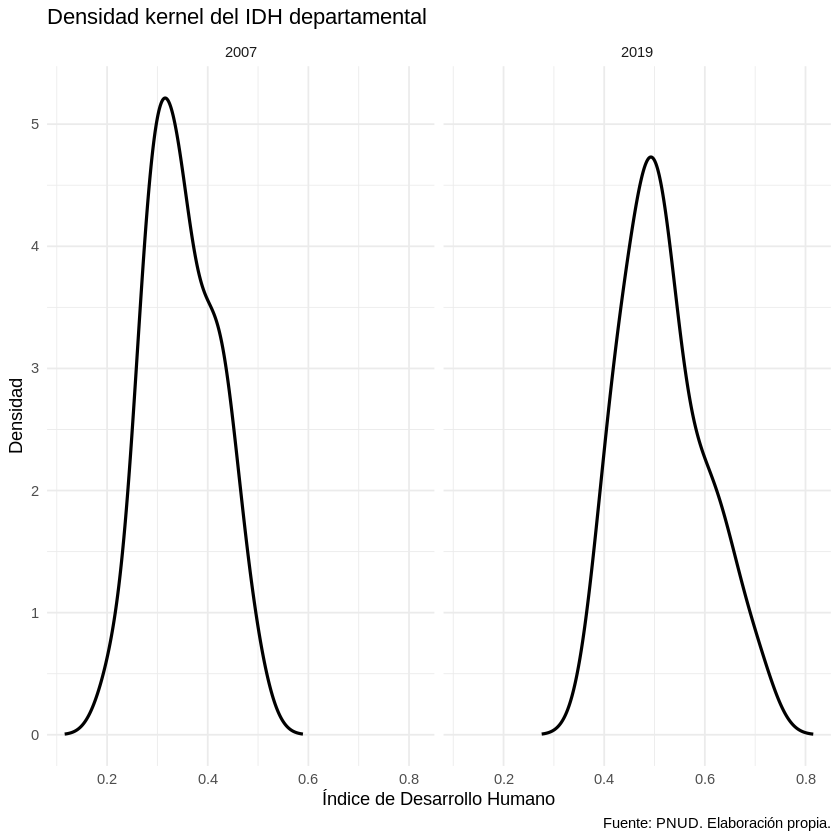

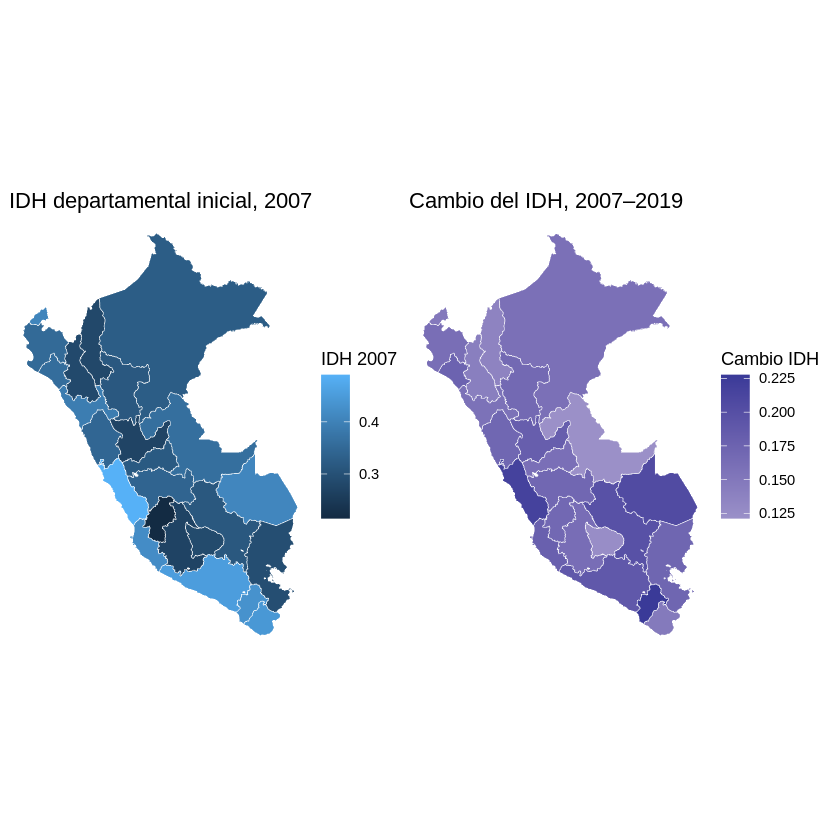

In [17]:
dens_2007 <- density(mapa_datos$idh_2007)
dens_2019 <- density(mapa_datos$idh_2019)

df_dens <- bind_rows(
  data.frame(x = dens_2007$x, densidad = dens_2007$y, periodo = "2007"),
  data.frame(x = dens_2019$x, densidad = dens_2019$y, periodo = "2019")
)

fig_densidad <- ggplot(df_dens, aes(x = x, y = densidad)) +
  geom_line(linewidth = 0.9) +
  facet_wrap(~periodo, nrow = 1) +
  labs(
    title = "Densidad kernel del IDH departamental",
    x = "Índice de Desarrollo Humano",
    y = "Densidad",
    caption = "Fuente: PNUD. Elaboración propia."
  ) +
  theme_minimal()

fig_mapa_nivel <- ggplot(mapa_datos) +
  geom_sf(aes(fill = idh_2007), color = "white", linewidth = 0.15) +
  scale_fill_gradient(name = "IDH 2007") +
  labs(title = "IDH departamental inicial, 2007") +
  theme_void()

fig_mapa_cambio <- ggplot(mapa_datos) +
  geom_sf(aes(fill = d_dev), color = "white", linewidth = 0.15) +
  scale_fill_gradient2(midpoint = 0, name = "Cambio IDH") +
  labs(title = "Cambio del IDH, 2007–2019") +
  theme_void()

fig_mapas <- fig_mapa_nivel + fig_mapa_cambio

ggsave("figures/figura_1_densidad_idh.png", fig_densidad, width = 9, height = 4.5, dpi = 300)
ggsave("figures/figura_2_mapas_idh.png", fig_mapas, width = 10, height = 5, dpi = 300)

fig_densidad
fig_mapas

### Interpretación de las Figuras 1 y 2

La distribución de 2019 se desplaza hacia la derecha respecto de 2007, lo que refleja una mejora general del desarrollo humano. Sin embargo, el desplazamiento no implica que todos los departamentos hayan avanzado al mismo ritmo. El mapa de variaciones muestra diferencias territoriales persistentes: algunos departamentos del centro y sur acumularon mejoras superiores, mientras que otras zonas registraron progresos más moderados. Por ello, el aumento del promedio debe analizarse conjuntamente con la dispersión y la localización geográfica de los cambios.

### 4.3 Autocorrelación espacial global

El índice global de Moran se define como:

$$
I=
\frac{n}{S_0}
\frac{
\displaystyle\sum_{i=1}^{n}\sum_{j=1}^{n}
w_{ij}(x_i-\bar{x})(x_j-\bar{x})
}{
\displaystyle\sum_{i=1}^{n}(x_i-\bar{x})^2
}
$$

donde $n$ representa el número de departamentos, $w_{ij}$ corresponde al peso espacial entre los departamentos $i$ y $j$, $\bar{x}$ es la media de la variable analizada y $S_0$ es la suma total de los pesos espaciales:

$$
S_0=
\sum_{i=1}^{n}
\sum_{j=1}^{n}
w_{ij}
$$

Un valor positivo y estadísticamente significativo indica agrupamiento espacial de valores semejantes, es decir, departamentos con niveles altos rodeados por departamentos con niveles altos, o unidades con valores bajos próximas a otras de valores bajos.

En cambio, un valor negativo y significativo sugiere una configuración espacial de contraste, en la que departamentos con valores altos se encuentran próximos a departamentos con valores bajos, o viceversa.

La ausencia de significancia estadística no demuestra que la dimensión espacial sea irrelevante. Con una muestra reducida de 24 departamentos, la prueba puede presentar baja potencia para detectar patrones espaciales moderados. Por ello, el resultado debe analizarse conjuntamente con los diagramas de Moran, las pruebas LM y los modelos espaciales posteriores.

**Figura 3**  
*Diagramas de Moran del IDH inicial y de su cambio acumulado, 2007–2019.*

**Nota.** La pendiente de la recta del diagrama corresponde al valor del índice global de Moran. Los cuadrantes alto–alto y bajo–bajo representan asociaciones espaciales positivas, mientras que los cuadrantes alto–bajo y bajo–alto reflejan posibles valores atípicos espaciales.

In [18]:
extraer_moran <- function(variable, nombre_variable, listw, nombre_matriz) {
  prueba <- moran.test(variable, listw, zero.policy = TRUE)
  tibble(
    variable = nombre_variable,
    matriz = nombre_matriz,
    moran_i = unname(prueba$estimate[["Moran I statistic"]]),
    esperanza = unname(prueba$estimate[["Expectation"]]),
    varianza = unname(prueba$estimate[["Variance"]]),
    p_valor = prueba$p.value
  )
}

tabla_moran <- bind_rows(
  extraer_moran(mapa_datos$idh_2007, "IDH 2007", W_dist, "Banda inversa"),
  extraer_moran(mapa_datos$d_dev, "Cambio IDH", W_dist, "Banda inversa"),
  extraer_moran(mapa_datos$ln_rgdpc_2007, "ln PBIpc 2007", W_dist, "Banda inversa"),
  extraer_moran(mapa_datos$d_rgdpc, "Cambio ln PBIpc", W_dist, "Banda inversa"),
  extraer_moran(mapa_datos$idh_2007, "IDH 2007", W_queen, "Queen"),
  extraer_moran(mapa_datos$d_dev, "Cambio IDH", W_queen, "Queen"),
  extraer_moran(mapa_datos$idh_2007, "IDH 2007", W_k4, "KNN k=4"),
  extraer_moran(mapa_datos$d_dev, "Cambio IDH", W_k4, "KNN k=4")
)

write.csv(tabla_moran, "tables/tabla_moran_global.csv", row.names = FALSE)
knitr::kable(tabla_moran, digits = 4, caption = "Tabla 4. Índice global de Moran según variable y matriz espacial")



Table: Tabla 4. Índice global de Moran según variable y matriz espacial

|variable        |matriz        | moran_i| esperanza| varianza| p_valor|
|:---------------|:-------------|-------:|---------:|--------:|-------:|
|IDH 2007        |Banda inversa | -0.0273|   -0.0435|   0.0133|  0.4443|
|Cambio IDH      |Banda inversa | -0.0662|   -0.0435|   0.0128|  0.5796|
|ln PBIpc 2007   |Banda inversa |  0.0692|   -0.0435|   0.0126|  0.1581|
|Cambio ln PBIpc |Banda inversa | -0.0769|   -0.0435|   0.0107|  0.6265|
|IDH 2007        |Queen         | -0.0690|   -0.0435|   0.0181|  0.5752|
|Cambio IDH      |Queen         | -0.0277|   -0.0435|   0.0175|  0.4525|
|IDH 2007        |KNN k=4       | -0.0713|   -0.0435|   0.0149|  0.5903|
|Cambio IDH      |KNN k=4       | -0.0799|   -0.0435|   0.0144|  0.6194|

In [19]:
m_idh <- tabla_moran |> filter(variable == "IDH 2007", matriz == "Banda inversa")
m_cambio <- tabla_moran |> filter(variable == "Cambio IDH", matriz == "Banda inversa")

lectura_moran <- function(i, p) {
  if (p < 0.05 && i > 0) return("autocorrelación espacial positiva y significativa")
  if (p < 0.05 && i < 0) return("autocorrelación espacial negativa y significativa")
  return("ausencia de evidencia estadística de autocorrelación global")
}

render_md(paste0(
  "### Interpretación de la Tabla 4\n\n",
  "Con la matriz principal, el IDH de 2007 presenta un Moran de **", fmt(m_idh$moran_i, 3),
  "** (p = **", fmt(m_idh$p_valor, 3), "**), lo que indica ", lectura_moran(m_idh$moran_i, m_idh$p_valor), ". ",
  "Para el cambio del IDH, el estadístico es **", fmt(m_cambio$moran_i, 3), "** (p = **",
  fmt(m_cambio$p_valor, 3), "**), con ", lectura_moran(m_cambio$moran_i, m_cambio$p_valor), ". ",
  "La comparación con queen y KNN debe usarse como prueba de sensibilidad, no como búsqueda de la matriz que produzca el resultado más conveniente."
))

### Interpretación de la Tabla 4

Con la matriz principal, el IDH de 2007 presenta un Moran de **-0.027** (p = **0.444**), lo que indica ausencia de evidencia estadística de autocorrelación global. Para el cambio del IDH, el estadístico es **-0.066** (p = **0.580**), con ausencia de evidencia estadística de autocorrelación global. La comparación con queen y KNN debe usarse como prueba de sensibilidad, no como búsqueda de la matriz que produzca el resultado más conveniente.

**Figura 3**  
*Diagramas de dispersión de Moran para el IDH inicial y su cambio acumulado.*

agg_record_21361e8c14c 
                     2

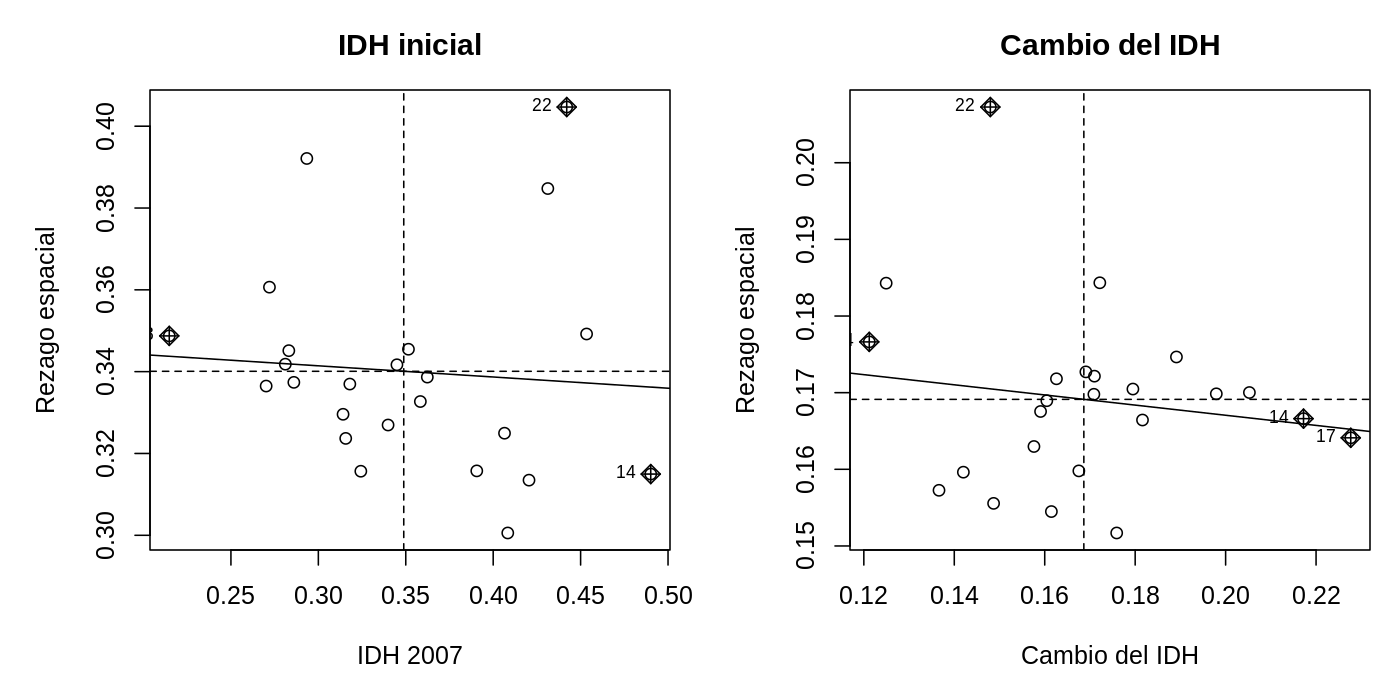

In [20]:
png("figures/figura_3_moran_scatter.png", width = 1400, height = 700, res = 150)
par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
moran.plot(
  mapa_datos$idh_2007, W_dist,
  zero.policy = TRUE,
  xlab = "IDH 2007",
  ylab = "Rezago espacial",
  main = "IDH inicial"
)
moran.plot(
  mapa_datos$d_dev, W_dist,
  zero.policy = TRUE,
  xlab = "Cambio del IDH",
  ylab = "Rezago espacial",
  main = "Cambio del IDH"
)
dev.off()

IRdisplay::display_png(file = "figures/figura_3_moran_scatter.png")

**Nota.** Los puntos alejados de la nube principal pueden influir en la pendiente del diagrama. Con 24 departamentos, la identificación de conglomerados globales es sensible a casos extremos y a la matriz seleccionada.

## 5. Regresiones de convergencia y pruebas LM

### 5.1 Convergencia beta absoluta

Para el Índice de Desarrollo Humano se estima:

$$
\Delta dev_i=
\alpha+
\beta dev_{i,2007}
+
\varepsilon_i
$$

donde:

$$
\Delta dev_i=
IDH_{i,2019}
-
IDH_{i,2007}
$$

Para el PBI real per cápita relativo se emplea:

$$
\Delta \ln(rgdpc_i)=
\alpha+
\beta\ln(rgdpc_{i,2007})
+
\varepsilon_i
$$

donde:

$$
\Delta \ln(rgdpc_i)=
\ln(rgdpc_{i,2019})
-
\ln(rgdpc_{i,2007})
$$

La interpretación del parámetro $\beta$ depende de su signo y significancia estadística:

- Si $\beta<0$ y es estadísticamente significativo, los departamentos con menor nivel inicial registran un avance relativamente mayor; por tanto, existe evidencia de convergencia beta.
- Si $\beta>0$ y es estadísticamente significativo, los departamentos con mejor posición inicial progresan más; ello es compatible con divergencia regional.
- Si $\beta$ no resulta estadísticamente significativo, no se dispone de evidencia suficiente para afirmar convergencia o divergencia durante el periodo analizado.

La convergencia beta no implica necesariamente convergencia sigma. La primera evalúa la relación entre la posición inicial y el crecimiento posterior, mientras que la segunda examina si disminuye la dispersión transversal entre departamentos.

### 5.2 Diagnósticos LM

Las pruebas de multiplicadores de Lagrange permiten determinar si la especificación lineal presenta dependencia espacial omitida. Se consideran principalmente dos alternativas:

- **LM-lag:** evalúa si existe dependencia espacial en la variable dependiente.
- **LM-error:** contrasta si la autocorrelación espacial se concentra en el término de error.

También se emplean sus versiones robustas:

- **Robust LM-lag**
- **Robust LM-error**

La regla de decisión se basa en el valor $p$:

- Si $p<0.05$, se rechaza la hipótesis nula de ausencia de dependencia espacial.
- Si solo el LM-lag robusto es significativo, se prioriza un modelo de rezago espacial.
- Si solo el LM-error robusto es significativo, se prioriza un modelo de error espacial.
- Si ambas pruebas robustas son significativas, se requiere comparar especificaciones más amplias y revisar criterios de información como el AIC.

Debido a que la muestra comprende únicamente 24 departamentos, los resultados de las pruebas LM deben interpretarse con cautela. Los valores $p$ se analizan conjuntamente con la estabilidad de los coeficientes entre matrices de pesos, la significancia del parámetro espacial y los criterios de información.

In [21]:
test = "all"

In [22]:
# ============================================================
# MODELOS OLS Y PRUEBAS DE DEPENDENCIA ESPACIAL RS/LM
# ============================================================

modelo_ols_dev <- lm(
  d_dev ~ idh_2007,
  data = mapa_datos
)

modelo_ols_rgdpc <- lm(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_datos
)

# ------------------------------------------------------------
# Función para ejecutar y organizar las pruebas RS/LM
# ------------------------------------------------------------

convertir_tests_lm <- function(modelo, listw, variable, matriz) {

  pruebas <- spdep::lm.RStests(
    model = modelo,
    listw = listw,
    test = "all",
    zero.policy = TRUE
  )

  # Extraer la tabla generada por el método summary()
  resultados <- summary(pruebas)$results
  resultados <- as.data.frame(resultados)

  # Construir una tabla uniforme
  tabla <- tibble::tibble(
    variable = variable,
    matriz = matriz,
    prueba = rownames(resultados),
    estadistico = as.numeric(resultados[[1]]),
    gl = as.numeric(resultados[[2]]),
    p_valor = as.numeric(resultados[[3]])
  ) |>
    dplyr::mutate(
      significancia = dplyr::case_when(
        p_valor < 0.01 ~ "***",
        p_valor < 0.05 ~ "**",
        p_valor < 0.10 ~ "*",
        TRUE ~ ""
      ),
      decision = dplyr::if_else(
        p_valor < 0.05,
        "Se rechaza H0",
        "No se rechaza H0"
      )
    )

  return(tabla)
}

# ------------------------------------------------------------
# Ejecutar las pruebas con ambas matrices espaciales
# ------------------------------------------------------------

tabla_lm <- dplyr::bind_rows(

  convertir_tests_lm(
    modelo = modelo_ols_dev,
    listw = W_dist,
    variable = "Cambio del IDH",
    matriz = "Banda de distancia inversa"
  ),

  convertir_tests_lm(
    modelo = modelo_ols_rgdpc,
    listw = W_dist,
    variable = "Cambio del ln PBI per cápita",
    matriz = "Banda de distancia inversa"
  ),

  convertir_tests_lm(
    modelo = modelo_ols_dev,
    listw = W_queen,
    variable = "Cambio del IDH",
    matriz = "Contigüidad queen"
  ),

  convertir_tests_lm(
    modelo = modelo_ols_rgdpc,
    listw = W_queen,
    variable = "Cambio del ln PBI per cápita",
    matriz = "Contigüidad queen"
  )
)

# ------------------------------------------------------------
# Orden y presentación
# ------------------------------------------------------------

tabla_lm <- tabla_lm |>
  dplyr::arrange(variable, matriz, prueba)

dir.create(
  "tables",
  showWarnings = FALSE,
  recursive = TRUE
)

write.csv(
  tabla_lm,
  "tables/tabla_pruebas_lm.csv",
  row.names = FALSE,
  fileEncoding = "UTF-8"
)

knitr::kable(
  tabla_lm,
  digits = 4,
  caption = paste(
    "Tabla 5.",
    "Pruebas de dependencia espacial de los modelos OLS"
  ),
  align = c("l", "l", "l", "r", "r", "r", "c", "l")
)



Table: Tabla 5. Pruebas de dependencia espacial de los modelos OLS

|variable                     |matriz                     |prueba   | estadistico| gl| p_valor| significancia |decision         |
|:----------------------------|:--------------------------|:--------|-----------:|--:|-------:|:-------------:|:----------------|
|Cambio del IDH               |Banda de distancia inversa |RSerr    |      0.6368|  1|  0.4249|               |No se rechaza H0 |
|Cambio del IDH               |Banda de distancia inversa |RSlag    |      0.6048|  1|  0.4368|               |No se rechaza H0 |
|Cambio del IDH               |Banda de distancia inversa |SARMA    |      0.6377|  2|  0.7270|               |No se rechaza H0 |
|Cambio del IDH               |Banda de distancia inversa |adjRSerr |      0.0329|  1|  0.8560|               |No se rechaza H0 |
|Cambio del IDH               |Banda de distancia inversa |adjRSlag |      0.0008|  1|  0.9770|               |No se rechaza H0 |
|Cambio del IDH     

In [23]:
resumir_lm <- function(variable_obj, matriz_obj) {
  sub <- tabla_lm |> filter(variable == variable_obj, matriz == matriz_obj)
  sig <- sub |> filter(p_valor < 0.05)
  if (nrow(sig) == 0) return("ninguna prueba rechaza la ausencia de dependencia espacial al 5%")
  paste0("resultan significativas: ", paste(sig$prueba, collapse = ", "))
}

render_md(paste0(
  "### Interpretación de la Tabla 5\n\n",
  "Para el cambio del IDH con banda inversa, ", resumir_lm("Cambio IDH", "Banda inversa"), ". ",
  "Para el cambio del PBI per cápita relativo, ", resumir_lm("Cambio ln PBIpc", "Banda inversa"), ". ",
  "La matriz queen actúa como contraste de robustez. Cuando RS-error y su versión robusta son significativas, el SEM tiene una justificación más directa; cuando las pruebas no son significativas, el modelo espacial se reporta como comprobación y no como sustituto obligatoria del OLS."
))

### Interpretación de la Tabla 5

Para el cambio del IDH con banda inversa, ninguna prueba rechaza la ausencia de dependencia espacial al 5%. Para el cambio del PBI per cápita relativo, ninguna prueba rechaza la ausencia de dependencia espacial al 5%. La matriz queen actúa como contraste de robustez. Cuando RS-error y su versión robusta son significativas, el SEM tiene una justificación más directa; cuando las pruebas no son significativas, el modelo espacial se reporta como comprobación y no como sustituto obligatoria del OLS.

### 5.3 Modelos espaciales

El modelo de error espacial es:

\[
y_i=\alpha+\beta x_i+u_i,
\qquad
u_i=\lambda\sum_jw_{ij}u_j+\varepsilon_i
\]

El modelo Durbin–SEM incorpora además el rezago espacial de la variable explicativa:

\[
y_i=\alpha+\beta x_i+\theta\sum_jw_{ij}x_j+u_i,
\qquad
u_i=\lambda Wu_i+\varepsilon_i
\]

En este contexto, \(\lambda\) representa dependencia espacial no observada en el término de error y \(\theta\) aproxima la asociación entre el resultado de un departamento y la condición inicial de su entorno.

### Interpretación de las pruebas de dependencia espacial

Los resultados de las pruebas RS/LM muestran comportamientos diferentes entre el desarrollo humano y el ingreso regional.

En el modelo del cambio del IDH, ninguna de las pruebas de dependencia espacial resulta estadísticamente significativa al nivel del 5 %, tanto con la matriz de banda de distancia inversa como con la matriz de contigüidad queen. En consecuencia, no se rechaza la hipótesis nula de ausencia de autocorrelación espacial residual o sustantiva. Este resultado indica que, para el periodo 2007–2019, las variaciones departamentales del IDH pueden ser analizadas inicialmente mediante una especificación OLS, sin que exista evidencia suficiente para justificar obligatoriamente un modelo espacial.

En el caso del cambio del PBI real per cápita relativo, los resultados son distintos. Con la matriz de banda de distancia inversa, la prueba robusta de error espacial es significativa al 5 % ($p=0.0405$), mientras que la prueba robusta de rezago espacial solo alcanza significancia al 10 % ($p=0.0837$). Con la matriz queen, tanto la prueba simple de error ($p=0.0401$) como la prueba robusta de error ($p=0.0123$) son significativas. Asimismo, la prueba conjunta SARMA resulta significativa ($p=0.0275$).

En conjunto, estos resultados sugieren que la dependencia espacial del modelo de ingreso se concentra principalmente en el término de error. Por esta razón, el modelo de error espacial (SEM) constituye la especificación preferente para analizar la convergencia del PBI per cápita. El modelo Durbin-SEM puede estimarse como una extensión de robustez, mientras que el modelo de rezago espacial no presenta respaldo suficiente al nivel de significancia del 5 %.

Debe considerarse que la muestra está conformada por 24 departamentos. Por ello, la potencia estadística de las pruebas es limitada y los resultados deben complementarse con la comparación de los coeficientes, el parámetro espacial, el AIC y la estabilidad entre las matrices de pesos.

### 5.3 Modelos espaciales

El modelo de error espacial (SEM) se especifica como:

$$
y_i=
\alpha+
\beta x_i+
u_i
$$

$$
u_i=
\lambda
\sum_{j=1}^{n}
w_{ij}u_j+
\varepsilon_i
$$

De manera matricial:

$$
\mathbf{y}
=
\alpha\mathbf{1}
+
\beta\mathbf{x}
+
\mathbf{u},
\qquad
\mathbf{u}
=
\lambda\mathbf{W}\mathbf{u}
+
\boldsymbol{\varepsilon}
$$

donde $y_i$ representa el cambio del indicador analizado, $x_i$ corresponde a su nivel inicial, $w_{ij}$ es el peso espacial entre los departamentos $i$ y $j$, y $\lambda$ mide la dependencia espacial presente en el término de error.

Cuando $\lambda$ es estadísticamente significativo, se infiere que existen factores omitidos con una distribución espacial que afectan de manera semejante a departamentos próximos. Estos factores pueden estar relacionados con infraestructura, accesibilidad, estructura productiva, instituciones, capital humano o condiciones territoriales no incorporadas explícitamente en la regresión.

El modelo Durbin–SEM amplía la especificación anterior al incorporar el rezago espacial de la variable explicativa:

$$
y_i=
\alpha+
\beta x_i+
\theta
\sum_{j=1}^{n}
w_{ij}x_j+
u_i
$$

$$
u_i=
\lambda
\sum_{j=1}^{n}
w_{ij}u_j+
\varepsilon_i
$$

En forma matricial:

$$
\mathbf{y}
=
\alpha\mathbf{1}
+
\beta\mathbf{x}
+
\theta\mathbf{W}\mathbf{x}
+
\mathbf{u},
\qquad
\mathbf{u}
=
\lambda\mathbf{W}\mathbf{u}
+
\boldsymbol{\varepsilon}
$$

En esta especificación, $\beta$ representa la relación entre la condición inicial del propio departamento y su variación posterior. El parámetro $\theta$ capta la asociación entre el resultado de un departamento y las condiciones iniciales ponderadas de los departamentos vecinos. Por su parte, $\lambda$ recoge la dependencia espacial asociada con factores no observados contenidos en el término de error.

La interpretación del parámetro $\theta$ debe realizarse con cautela. Un coeficiente significativo indica que el desempeño posterior de un departamento se encuentra relacionado con la situación inicial de su entorno espacial, aunque no implica necesariamente una relación causal directa. Su signo permite identificar si las condiciones iniciales de los departamentos vecinos favorecen o limitan el proceso de convergencia regional.

#### 5.3.1 Matriz principal: banda de distancia inversa

In [24]:
modelo_sem_dev_dist <- errorsarlm(
  d_dev ~ idh_2007,
  data = mapa_datos,
  listw = W_dist,
  zero.policy = TRUE,
  method = "eigen"
)

modelo_durbin_sem_dev_dist <- errorsarlm(
  d_dev ~ idh_2007,
  data = mapa_datos,
  listw = W_dist,
  Durbin = TRUE,
  zero.policy = TRUE,
  method = "eigen"
)

modelo_sem_rgdpc_dist <- errorsarlm(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_datos,
  listw = W_dist,
  zero.policy = TRUE,
  method = "eigen"
)

modelo_durbin_sem_rgdpc_dist <- errorsarlm(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_datos,
  listw = W_dist,
  Durbin = TRUE,
  zero.policy = TRUE,
  method = "eigen"
)


cat("Modelos con banda inversa estimados.\n")

Modelos con banda inversa estimados.


#### 5.3.2 Robustez: contigüidad queen

In [25]:
modelo_sem_dev_queen <- errorsarlm(
  d_dev ~ idh_2007,
  data = mapa_datos,
  listw = W_queen,
  zero.policy = TRUE,
  method = "eigen"
)

modelo_durbin_sem_dev_queen <- errorsarlm(
  d_dev ~ idh_2007,
  data = mapa_datos,
  listw = W_queen,
  Durbin = TRUE,
  zero.policy = TRUE,
  method = "eigen"
)

modelo_sem_rgdpc_queen <- errorsarlm(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_datos,
  listw = W_queen,
  zero.policy = TRUE,
  method = "eigen"
)

modelo_durbin_sem_rgdpc_queen <- errorsarlm(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_datos,
  listw = W_queen,
  Durbin = TRUE,
  zero.policy = TRUE,
  method = "eigen"
)

cat("Modelos con matriz queen estimados.\n")

Modelos con matriz queen estimados.


In [26]:
ordenar_modelo <- function(modelo_obj, nombre, variable, matriz) {
  aic_val <- AIC(modelo_obj)

  if (inherits(modelo_obj, "lm")) {
    resultado <- broom::tidy(modelo_obj)
    lambda_val <- NA_real_
  } else {
    matriz_coef <- as.data.frame(summary(modelo_obj)$Coef)
    resultado <- tibble(
      term = rownames(matriz_coef),
      estimate = matriz_coef[, 1],
      std.error = matriz_coef[, 2],
      statistic = matriz_coef[, 3],
      p.value = matriz_coef[, 4]
    )
    lambda_val <- modelo_obj$lambda
  }

  resultado |>
    mutate(
      modelo = nombre,
      variable_dependiente = variable,
      matriz = matriz,
      lambda = lambda_val,
      AIC = aic_val
    ) |>
    select(variable_dependiente, matriz, modelo, term, estimate, std.error, statistic, p.value, lambda, AIC)
}

tabla_regresiones <- bind_rows(
  ordenar_modelo(modelo_ols_dev, "OLS", "Cambio IDH", "Sin matriz"),
  ordenar_modelo(modelo_sem_dev_dist, "SEM", "Cambio IDH", "Banda inversa"),
  ordenar_modelo(modelo_durbin_sem_dev_dist, "Durbin-SEM", "Cambio IDH", "Banda inversa"),
  ordenar_modelo(modelo_sem_dev_queen, "SEM", "Cambio IDH", "Queen"),
  ordenar_modelo(modelo_durbin_sem_dev_queen, "Durbin-SEM", "Cambio IDH", "Queen"),
  ordenar_modelo(modelo_ols_rgdpc, "OLS", "Cambio ln PBIpc", "Sin matriz"),
  ordenar_modelo(modelo_sem_rgdpc_dist, "SEM", "Cambio ln PBIpc", "Banda inversa"),
  ordenar_modelo(modelo_durbin_sem_rgdpc_dist, "Durbin-SEM", "Cambio ln PBIpc", "Banda inversa"),
  ordenar_modelo(modelo_sem_rgdpc_queen, "SEM", "Cambio ln PBIpc", "Queen"),
  ordenar_modelo(modelo_durbin_sem_rgdpc_queen, "Durbin-SEM", "Cambio ln PBIpc", "Queen")
)

write.csv(tabla_regresiones, "tables/tabla_resultados_regresion.csv", row.names = FALSE)

tabla_reg_distancia <- tabla_regresiones |>
  filter(matriz %in% c("Sin matriz", "Banda inversa"))

tabla_reg_queen <- tabla_regresiones |>
  filter(matriz %in% c("Queen"))

knitr::kable(
  tabla_reg_distancia,
  digits = 4,
  caption = "Tabla 6. Resultados de convergencia con banda de distancia inversa"
)

knitr::kable(
  tabla_reg_queen,
  digits = 4,
  caption = "Tabla 7. Resultados de robustez con contigüidad queen"
)



Table: Tabla 6. Resultados de convergencia con banda de distancia inversa

|variable_dependiente |matriz        |modelo     |term              | estimate| std.error| statistic| p.value|  lambda|       AIC|
|:--------------------|:-------------|:----------|:-----------------|--------:|---------:|---------:|-------:|-------:|---------:|
|Cambio IDH           |Sin matriz    |OLS        |(Intercept)       |   0.1115|    0.0260|    4.2965|  0.0003|      NA| -106.4696|
|Cambio IDH           |Sin matriz    |OLS        |idh_2007          |   0.1637|    0.0731|    2.2406|  0.0355|      NA| -106.4696|
|Cambio IDH           |Banda inversa |SEM        |(Intercept)       |   0.1094|    0.0240|    4.5629|  0.0000| -0.3166| -105.2509|
|Cambio IDH           |Banda inversa |SEM        |idh_2007          |   0.1712|    0.0684|    2.5026|  0.0123| -0.3166| -105.2509|
|Cambio IDH           |Banda inversa |Durbin-SEM |(Intercept)       |   0.0991|    0.0592|    1.6739|  0.0942| -0.3321| -103.2841|
|Cambi



Table: Tabla 7. Resultados de robustez con contigüidad queen

|variable_dependiente |matriz |modelo     |term              | estimate| std.error| statistic| p.value|  lambda|       AIC|
|:--------------------|:------|:----------|:-----------------|--------:|---------:|---------:|-------:|-------:|---------:|
|Cambio IDH           |Queen  |SEM        |(Intercept)       |   0.1035|    0.0243|    4.2654|  0.0000| -0.3117| -105.3478|
|Cambio IDH           |Queen  |SEM        |idh_2007          |   0.1882|    0.0689|    2.7312|  0.0063| -0.3117| -105.3478|
|Cambio IDH           |Queen  |Durbin-SEM |(Intercept)       |   0.0107|    0.0542|    0.1976|  0.8434| -0.4470| -106.2370|
|Cambio IDH           |Queen  |Durbin-SEM |idh_2007          |   0.1782|    0.0654|    2.7247|  0.0064| -0.4470| -106.2370|
|Cambio IDH           |Queen  |Durbin-SEM |lag.idh_2007      |   0.2782|    0.1541|    1.8054|  0.0710| -0.4470| -106.2370|
|Cambio ln PBIpc      |Queen  |SEM        |(Intercept)       |   0.0

**Nota.** Los niveles de significancia se evalúan con los p-valores reportados. El AIC menor indica mejor ajuste relativo entre modelos estimados sobre la misma variable dependiente. La comparación no debe limitarse al AIC: también importa la coherencia del signo, la significancia y los diagnósticos LM.

In [27]:
obtener_beta <- function(dep, matriz_obj, modelo_obj, termino_obj) {
  tabla_regresiones |>
    filter(
      variable_dependiente == dep,
      matriz == matriz_obj,
      modelo == modelo_obj,
      term == termino_obj
    ) |>
    slice(1)
}

b_dev_ols <- obtener_beta("Cambio IDH", "Sin matriz", "OLS", "idh_2007")
b_pbi_ols <- obtener_beta("Cambio ln PBIpc", "Sin matriz", "OLS", "ln_rgdpc_2007")
b_dev_sem <- obtener_beta("Cambio IDH", "Banda inversa", "SEM", "idh_2007")
b_pbi_sem <- obtener_beta("Cambio ln PBIpc", "Banda inversa", "SEM", "ln_rgdpc_2007")

lectura_beta <- function(beta) {
  ifelse(beta < 0, "convergencia beta", "divergencia o ausencia de convergencia")
}

render_md(paste0(
  "### Interpretación de las Tablas 6 y 7\n\n",
  "En OLS, el coeficiente inicial del IDH es **", fmt(b_dev_ols$estimate, 4), "** (p = **",
  fmt(b_dev_ols$p.value, 4), "**), resultado ", significancia(b_dev_ols$p.value),
  " y asociado con **", lectura_beta(b_dev_ols$estimate), "**. ",
  "Para el PBI per cápita relativo, el coeficiente OLS es **", fmt(b_pbi_ols$estimate, 4),
  "** (p = **", fmt(b_pbi_ols$p.value, 4), "**), compatible con **", lectura_beta(b_pbi_ols$estimate), "**.\n\n",
  "Con la matriz principal, el SEM del IDH estima un beta de **", fmt(b_dev_sem$estimate, 4),
  "**, mientras que el SEM del PBI per cápita estima **", fmt(b_pbi_sem$estimate, 4), "**. ",
  "La conclusión sustantiva se considera robusta si el signo y la significancia se mantienen al cambiar de banda inversa a queen. ",
  "Las diferencias entre desarrollo humano e ingreso muestran que una mejora económica relativa no necesariamente se traduce en igualación multidimensional del bienestar."
))

### Interpretación de las Tablas 6 y 7

En OLS, el coeficiente inicial del IDH es **0.1637** (p = **0.0355**), resultado estadísticamente significativo al 5% y asociado con **divergencia o ausencia de convergencia**. Para el PBI per cápita relativo, el coeficiente OLS es **-0.3282** (p = **0.0004**), compatible con **convergencia beta**.

Con la matriz principal, el SEM del IDH estima un beta de **0.1712**, mientras que el SEM del PBI per cápita estima **-0.3666**. La conclusión sustantiva se considera robusta si el signo y la significancia se mantienen al cambiar de banda inversa a queen. Las diferencias entre desarrollo humano e ingreso muestran que una mejora económica relativa no necesariamente se traduce en igualación multidimensional del bienestar.

## 6. Regresión geográficamente ponderada

La GWR permite que la relación de convergencia cambie según la localización:

\[
y_i=\alpha(u_i,v_i)+\beta(u_i,v_i)x_i+\varepsilon_i
\]

Cada estimación local utiliza ponderaciones que disminuyen con la distancia. Un ancho de banda cercano a la extensión total del país implica que las observaciones reciben pesos similares y que el modelo local se aproxima a una regresión global.

In [28]:
# Proyección métrica apropiada para el territorio peruano.
mapa_gwr <- st_transform(mapa_datos, 32718)
coords_gwr <- st_coordinates(st_point_on_surface(st_geometry(mapa_gwr)))
mapa_gwr_sp <- as(mapa_gwr, "Spatial")

bw_dev_m <- gwr.sel(
  d_dev ~ idh_2007,
  data = mapa_gwr_sp,
  coords = coords_gwr,
  gweight = gwr.Gauss,
  verbose = FALSE
)

gwr_dev <- gwr(
  d_dev ~ idh_2007,
  data = mapa_gwr_sp,
  coords = coords_gwr,
  bandwidth = bw_dev_m,
  gweight = gwr.Gauss,
  hatmatrix = TRUE,
  se.fit = TRUE
)

bw_rgdpc_m <- gwr.sel(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_gwr_sp,
  coords = coords_gwr,
  gweight = gwr.Gauss,
  verbose = FALSE
)

gwr_rgdpc <- gwr(
  d_rgdpc ~ ln_rgdpc_2007,
  data = mapa_gwr_sp,
  coords = coords_gwr,
  bandwidth = bw_rgdpc_m,
  gweight = gwr.Gauss,
  hatmatrix = TRUE,
  se.fit = TRUE
)

distancia_maxima_m <- max(as.matrix(dist(coords_gwr)))

diagnostico_gwr <- tibble(
  variable = c("IDH", "PBI per cápita"),
  bandwidth_km = c(bw_dev_m, bw_rgdpc_m) / 1000,
  proporcion_distancia_maxima = c(bw_dev_m, bw_rgdpc_m) / distancia_maxima_m,
  beta_global = c(coef(modelo_ols_dev)[["idh_2007"]], coef(modelo_ols_rgdpc)[["ln_rgdpc_2007"]]),
  beta_local_min = c(min(gwr_dev$SDF$idh_2007), min(gwr_rgdpc$SDF$ln_rgdpc_2007)),
  beta_local_max = c(max(gwr_dev$SDF$idh_2007), max(gwr_rgdpc$SDF$ln_rgdpc_2007)),
  rango_beta_local = c(diff(range(gwr_dev$SDF$idh_2007)), diff(range(gwr_rgdpc$SDF$ln_rgdpc_2007)))
)

write.csv(diagnostico_gwr, "tables/tabla_diagnostico_gwr.csv", row.names = FALSE)
knitr::kable(diagnostico_gwr, digits = 4, caption = "Tabla 8. Diagnóstico de los modelos GWR")

Warning message in gwr.sel(d_dev ~ idh_2007, data = mapa_gwr_sp, coords = coords_gwr, :
“data is Spatial* object, ignoring coords argument”
Warning message in gwr.sel(d_dev ~ idh_2007, data = mapa_gwr_sp, coords = coords_gwr, :
“Bandwidth converged to upper bound:1919102.72069019”
Warning message in gwr(d_dev ~ idh_2007, data = mapa_gwr_sp, coords = coords_gwr, :
“data is Spatial* object, ignoring coords argument”
Warning message in gwr.sel(d_rgdpc ~ ln_rgdpc_2007, data = mapa_gwr_sp, coords = coords_gwr, :
“data is Spatial* object, ignoring coords argument”
Warning message in gwr(d_rgdpc ~ ln_rgdpc_2007, data = mapa_gwr_sp, coords = coords_gwr, :
“data is Spatial* object, ignoring coords argument”




Table: Tabla 8. Diagnóstico de los modelos GWR

|variable       | bandwidth_km| proporcion_distancia_maxima| beta_global| beta_local_min| beta_local_max| rango_beta_local|
|:--------------|------------:|---------------------------:|-----------:|--------------:|--------------:|----------------:|
|IDH            |     1919.103|                      1.0142|      0.1637|         0.1625|         0.1652|           0.0027|
|PBI per cápita |      360.547|                      0.1905|     -0.3282|        -0.4857|        -0.2771|           0.2086|

In [29]:
g_idh <- diagnostico_gwr |> filter(variable == "IDH")
g_pbi <- diagnostico_gwr |> filter(variable == "PBI per cápita")

lectura_gwr_idh <- ifelse(
  g_idh$proporcion_distancia_maxima > 0.90 && g_idh$rango_beta_local < 0.01,
  "el GWR del IDH se comporta prácticamente como un modelo global",
  "el GWR del IDH conserva variación local apreciable"
)

render_md(paste0(
  "### Interpretación de la Tabla 8\n\n",
  "El ancho de banda del IDH equivale a **", fmt(g_idh$bandwidth_km, 1), " km** y representa **",
  fmt(100 * g_idh$proporcion_distancia_maxima, 1), "%** de la distancia máxima entre centroides; ", lectura_gwr_idh, ". ",
  "El beta local del IDH varía solo entre **", fmt(g_idh$beta_local_min, 4), "** y **", fmt(g_idh$beta_local_max, 4), "**. ",
  "Esto no prueba que la heterogeneidad real sea nula: con 24 unidades, la selección del ancho de banda tiene poca potencia para identificar variaciones pequeñas.\n\n",
  "En el PBI per cápita, el beta local se extiende de **", fmt(g_pbi$beta_local_min, 4), "** a **",
  fmt(g_pbi$beta_local_max, 4), "**. La mayor amplitud permite una lectura territorial de velocidades de convergencia distintas."
))

### Interpretación de la Tabla 8

El ancho de banda del IDH equivale a **1919.1 km** y representa **101.4%** de la distancia máxima entre centroides; el GWR del IDH se comporta prácticamente como un modelo global. El beta local del IDH varía solo entre **0.1625** y **0.1652**. Esto no prueba que la heterogeneidad real sea nula: con 24 unidades, la selección del ancho de banda tiene poca potencia para identificar variaciones pequeñas.

En el PBI per cápita, el beta local se extiende de **-0.4857** a **-0.2771**. La mayor amplitud permite una lectura territorial de velocidades de convergencia distintas.

**Figura 4**  
*Coeficientes y bondad de ajuste local de los modelos GWR.*

**Figura 5**  
*Distribución departamental del beta local del PBI per cápita.*

Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


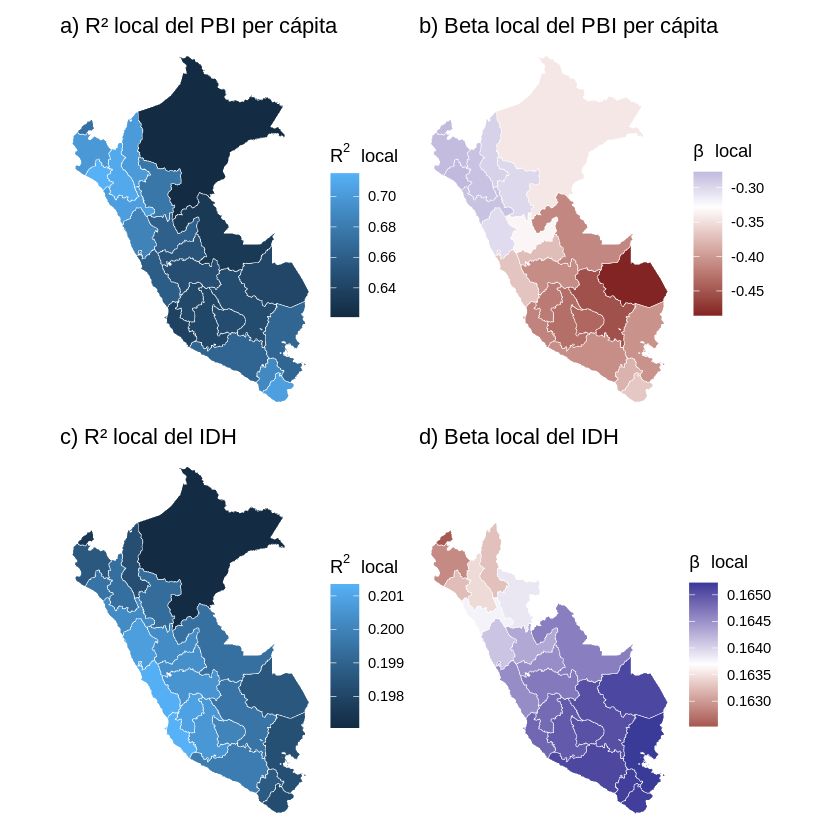

In [30]:
mapa_datos$beta_local_dev <- gwr_dev$SDF$idh_2007
mapa_datos$r2_local_dev <- gwr_dev$SDF$localR2
mapa_datos$beta_local_rgdpc <- gwr_rgdpc$SDF$ln_rgdpc_2007
mapa_datos$r2_local_rgdpc <- gwr_rgdpc$SDF$localR2

p_gwr_r2_pbi <- ggplot(mapa_datos) +
  geom_sf(aes(fill = r2_local_rgdpc), color = "white", linewidth = 0.15) +
  scale_fill_gradient(name = expression(R^2~local)) +
  labs(title = "a) R² local del PBI per cápita") +
  theme_void()

p_gwr_beta_pbi <- ggplot(mapa_datos) +
  geom_sf(aes(fill = beta_local_rgdpc), color = "white", linewidth = 0.15) +
  scale_fill_gradient2(
    midpoint = coef(modelo_ols_rgdpc)[["ln_rgdpc_2007"]],
    name = expression(beta~local)
  ) +
  labs(title = "b) Beta local del PBI per cápita") +
  theme_void()

p_gwr_r2_idh <- ggplot(mapa_datos) +
  geom_sf(aes(fill = r2_local_dev), color = "white", linewidth = 0.15) +
  scale_fill_gradient(name = expression(R^2~local)) +
  labs(title = "c) R² local del IDH") +
  theme_void()

p_gwr_beta_idh <- ggplot(mapa_datos) +
  geom_sf(aes(fill = beta_local_dev), color = "white", linewidth = 0.15) +
  scale_fill_gradient2(
    midpoint = coef(modelo_ols_dev)[["idh_2007"]],
    name = expression(beta~local)
  ) +
  labs(title = "d) Beta local del IDH") +
  theme_void()

fig_gwr <- (p_gwr_r2_pbi + p_gwr_beta_pbi) / (p_gwr_r2_idh + p_gwr_beta_idh)

p_gwr <- ggplot(mapa_datos) +
  geom_sf(aes(fill = beta_local_rgdpc), color = "white", linewidth = 0.15) +
  scale_fill_gradient2(
    midpoint = coef(modelo_ols_rgdpc)[["ln_rgdpc_2007"]],
    name = expression(beta~local)
  ) +
  geom_sf_text(aes(label = clave), size = 2, check_overlap = TRUE) +
  labs(
    title = "Coeficiente local de convergencia del PBI per cápita",
    subtitle = "Perú, 2007–2019",
    caption = "Fuente: INEI. Elaboración propia."
  ) +
  theme_void()

ggsave("figures/figura_4_gwr_paneles.png", fig_gwr, width = 10, height = 8, dpi = 300)
ggsave("figures/figura_5_gwr_beta_pbi.png", p_gwr, width = 8, height = 6, dpi = 300)

fig_gwr

### Interpretación de las Figuras 4 y 5

Los coeficientes locales del PBI per cápita son negativos en todo el territorio, por lo que el patrón general es de convergencia económica. La intensidad no es uniforme: los betas de mayor magnitud absoluta se concentran principalmente en parte del sur y del oriente, mientras que en el norte la convergencia es más lenta. En contraste, el mapa del IDH presenta diferencias cromáticas muy pequeñas, coherentes con el ancho de banda casi nacional. Esta aparente uniformidad debe exponerse como un resultado limitado por la escala departamental y no como evidencia definitiva de homogeneidad territorial.

## 7. Regresiones no paramétricas

Los ajustes LOESS y kernel permiten relajar el supuesto de linealidad impuesto por la regresión convencional. En términos generales, la relación se expresa como:

$$
y_i=
\alpha+
f(x_i)+
\varepsilon_i
$$

donde $y_i$ representa el cambio del indicador analizado, $x_i$ corresponde a su nivel inicial y $f(x_i)$ es una función desconocida que se estima de manera flexible a partir de los datos.

El ajuste LOESS realiza regresiones locales utilizando subconjuntos de observaciones próximas a cada punto. De esta manera, permite identificar cambios en la pendiente de la relación entre la condición inicial y el desempeño posterior.

Por su parte, el estimador kernel de Nadaraya–Watson se define como:

$$
\widehat{f}(x)=
\frac{
\displaystyle\sum_{i=1}^{n}
K\left(
\frac{x-x_i}{h}
\right)y_i
}{
\displaystyle\sum_{i=1}^{n}
K\left(
\frac{x-x_i}{h}
\right)
}
$$

donde $K(\cdot)$ representa la función kernel y $h$ corresponde al ancho de banda. El parámetro $h$ controla el grado de suavizamiento de la curva: valores pequeños producen ajustes más sensibles a variaciones locales, mientras que valores grandes generan trayectorias más suaves.

Estas estimaciones se utilizan como complemento de los modelos lineales y espaciales. Una pendiente negativa a lo largo de la mayor parte de la curva es compatible con convergencia, mientras que una pendiente positiva sugiere divergencia. Si la pendiente cambia de signo, la relación puede ser no lineal y diferir según el nivel inicial de desarrollo o ingreso.

Debido a que la muestra comprende 24 departamentos, la forma de las curvas en los extremos de la distribución debe interpretarse con cautela, ya que puede estar influida por un número reducido de observaciones. Por ello, los resultados no paramétricos se consideran evidencia complementaria y no sustituyen la inferencia obtenida mediante los modelos OLS, SEM y Durbin–SEM.

**Figura 6**  
*Ajustes lineal, LOESS y kernel para el IDH y el PBI real per cápita relativo.*

**Nota.** La figura compara la forma funcional estimada mediante tres métodos. La regresión lineal impone una pendiente constante, mientras que LOESS y kernel permiten identificar variaciones locales y posibles relaciones no lineales entre la condición inicial y el cambio observado durante 2007–2019.

Warning message in geom_smooth(method = "loess", span = 0.75, degree = 1, se = FALSE):
“Ignoring unknown parameters: `degree`”
Warning message in geom_smooth(method = "loess", span = 0.75, degree = 1, se = FALSE):
“Ignoring unknown parameters: `degree`”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


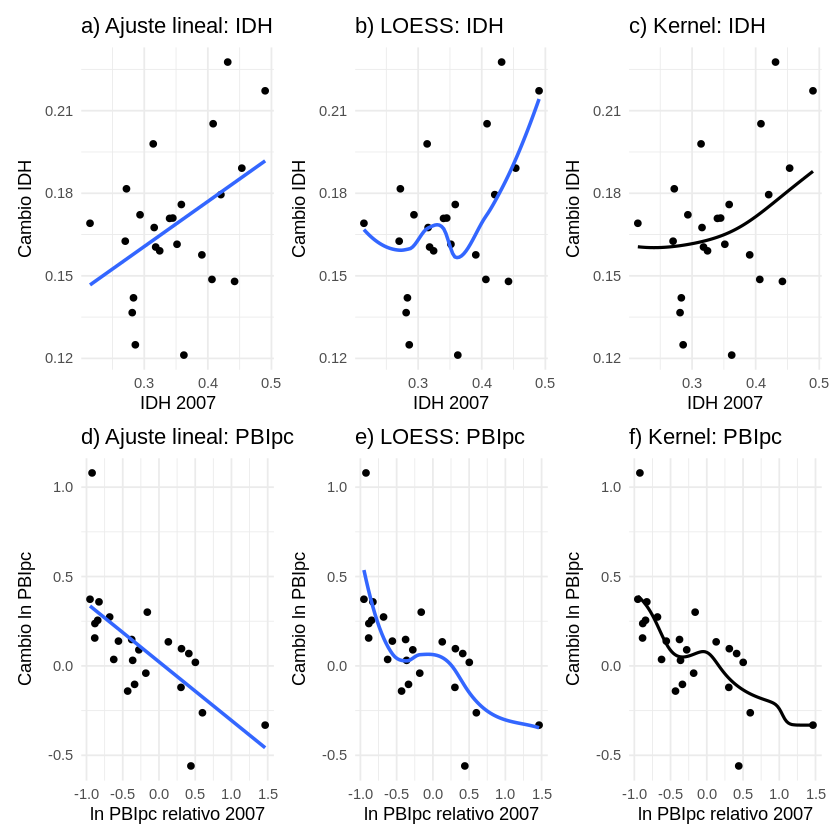

In [31]:
loess_dev <- loess(d_dev ~ idh_2007, data = mapa_datos, span = 0.75, degree = 1)
loess_rgdpc <- loess(d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos, span = 0.75, degree = 1)

kernel_dev <- ksmooth(
  mapa_datos$idh_2007,
  mapa_datos$d_dev,
  kernel = "normal",
  bandwidth = 0.15
)

kernel_rgdpc <- ksmooth(
  mapa_datos$ln_rgdpc_2007,
  mapa_datos$d_rgdpc,
  kernel = "normal",
  bandwidth = 0.50
)

p_lineal_dev <- ggplot(mapa_datos, aes(idh_2007, d_dev)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "a) Ajuste lineal: IDH", x = "IDH 2007", y = "Cambio IDH") +
  theme_minimal()

p_loess_dev <- ggplot(mapa_datos, aes(idh_2007, d_dev)) +
  geom_point() +
  geom_smooth(method = "loess", span = 0.75, degree = 1, se = FALSE) +
  labs(title = "b) LOESS: IDH", x = "IDH 2007", y = "Cambio IDH") +
  theme_minimal()

p_kernel_dev <- ggplot(mapa_datos, aes(idh_2007, d_dev)) +
  geom_point() +
  geom_line(
    data = data.frame(x = kernel_dev$x, y = kernel_dev$y),
    aes(x, y),
    linewidth = 0.9
  ) +
  labs(title = "c) Kernel: IDH", x = "IDH 2007", y = "Cambio IDH") +
  theme_minimal()

p_lineal_pbi <- ggplot(mapa_datos, aes(ln_rgdpc_2007, d_rgdpc)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "d) Ajuste lineal: PBIpc", x = "ln PBIpc relativo 2007", y = "Cambio ln PBIpc") +
  theme_minimal()

p_loess_pbi <- ggplot(mapa_datos, aes(ln_rgdpc_2007, d_rgdpc)) +
  geom_point() +
  geom_smooth(method = "loess", span = 0.75, degree = 1, se = FALSE) +
  labs(title = "e) LOESS: PBIpc", x = "ln PBIpc relativo 2007", y = "Cambio ln PBIpc") +
  theme_minimal()

p_kernel_pbi <- ggplot(mapa_datos, aes(ln_rgdpc_2007, d_rgdpc)) +
  geom_point() +
  geom_line(
    data = data.frame(x = kernel_rgdpc$x, y = kernel_rgdpc$y),
    aes(x, y),
    linewidth = 0.9
  ) +
  labs(title = "f) Kernel: PBIpc", x = "ln PBIpc relativo 2007", y = "Cambio ln PBIpc") +
  theme_minimal()

fig_no_parametrica <- (p_lineal_dev + p_loess_dev + p_kernel_dev) /
  (p_lineal_pbi + p_loess_pbi + p_kernel_pbi)

ggsave(
  "figures/figura_6_regresiones_no_parametricas.png",
  fig_no_parametrica,
  width = 13,
  height = 8,
  dpi = 300
)

fig_no_parametrica

### Interpretación de la Figura 6

En el caso del IDH, la línea global y los suavizados no paramétricos muestran una relación predominantemente positiva entre el nivel inicial y el avance posterior. Los departamentos con mayor IDH en 2007 tendieron, en promedio, a registrar incrementos iguales o mayores, lo que no respalda convergencia beta del desarrollo humano durante el periodo. La curva presenta ondulaciones intermedias, pero estas no deben sobredimensionarse por el reducido número de observaciones.

Para el PBI per cápita relativo, los tres ajustes conservan una pendiente general negativa: los departamentos inicialmente por debajo del promedio nacional mejoraron más su posición relativa. La curvatura sugiere que la velocidad de acercamiento no fue idéntica en toda la distribución, especialmente entre los departamentos ubicados en los extremos.

## 8. Síntesis empírica

1. El IDH promedio aumentó entre 2007 y 2019, pero la regresión beta no muestra que los departamentos inicialmente rezagados hayan avanzado con mayor rapidez.
2. El PBI per cápita relativo presenta un coeficiente beta negativo y significativo en la especificación global, compatible con convergencia económica.
3. La dependencia espacial del IDH es débil en los indicadores globales. Para el PBI per cápita, los diagnósticos y modelos espaciales deben compararse entre la banda inversa y queen.
4. La GWR identifica heterogeneidad territorial visible en la convergencia del ingreso. Para el IDH, el ancho de banda alcanza prácticamente la escala nacional y reduce el modelo a un comportamiento cercano al global.
5. Los resultados no paramétricos confirman que la convergencia económica no es perfectamente lineal y que la evolución del IDH sigue una trayectoria distinta de la del ingreso.

## 9. Comprobaciones finales y exportación

In [32]:
# Verificar que no existan datos faltantes en las variables centrales.
variables_clave <- mapa_datos |>
  st_drop_geometry() |>
  select(idh_2007, idh_2019, d_dev, ln_rgdpc_2007, ln_rgdpc_2019, d_rgdpc)

stopifnot(!anyNA(variables_clave))
stopifnot(nrow(variables_clave) == 24)

# Guardar base geográfica y resultados.
st_write(
  mapa_datos,
  "data/processed/mapa_datos_convergencia.gpkg",
  delete_dsn = TRUE,
  quiet = TRUE
)

capture.output(summary(modelo_ols_dev), file = "tables/resumen_ols_idh.txt")
capture.output(summary(modelo_ols_rgdpc), file = "tables/resumen_ols_pbi.txt")
capture.output(summary(modelo_sem_dev_dist), file = "tables/resumen_sem_idh_distancia.txt")
capture.output(summary(modelo_sem_rgdpc_dist), file = "tables/resumen_sem_pbi_distancia.txt")
capture.output(summary(gwr_dev), file = "tables/resumen_gwr_idh.txt")
capture.output(summary(gwr_rgdpc), file = "tables/resumen_gwr_pbi.txt")

archivos_salida <- c(
  list.files("data/processed", recursive = TRUE, full.names = TRUE),
  list.files("tables", recursive = TRUE, full.names = TRUE),
  list.files("figures", recursive = TRUE, full.names = TRUE)
)

zip("resultados_replica_peru.zip", archivos_salida)

cat("Proceso terminado.\n")
cat("Base analítica:", nrow(panel_final), "departamentos.\n")
cat("Umbral de la matriz principal:", round(d0, 2), "km.\n")
cat("Archivos exportados:", length(archivos_salida), "\n")

Proceso terminado.
Base analítica: 24 departamentos.
Umbral de la matriz principal: 407.1 km.
Archivos exportados: 20 


Al finalizar se genera `resultados_replica_peru.zip`, que contiene la base procesada, tablas en CSV, resúmenes de modelos y figuras en PNG a 300 dpi. Este archivo debe subirse al repositorio junto con el notebook ejecutado.

## 10. Limitaciones metodológicas

1. La muestra contiene 24 departamentos, muy por debajo de las 67 provincias utilizadas por el artículo de referencia. Esto reduce la potencia de Moran, las pruebas LM y la GWR.
2. El periodo 2007–2019 comprende doce años; por tanto, no reproduce la perspectiva de 46–54 años del estudio original y puede estar influido por condiciones coyunturales.
3. El IDH del PNUD se utiliza directamente en su escala 0–1. Es una adaptación razonable, pero no equivale a la normalización min–max del índice SED del artículo original.
4. El ancho de banda del GWR del IDH converge al límite superior. La escasa variación local puede reflejar falta de potencia y no necesariamente ausencia real de heterogeneidad.
5. Los resultados dependen de la definición de vecindad. Por esa razón, la banda de distancia inversa es la matriz principal y queen constituye una prueba de robustez.
6. Los suavizados LOESS y kernel son sensibles a observaciones extremas. Sus curvas deben interpretarse como evidencia complementaria y no como una prueba causal.

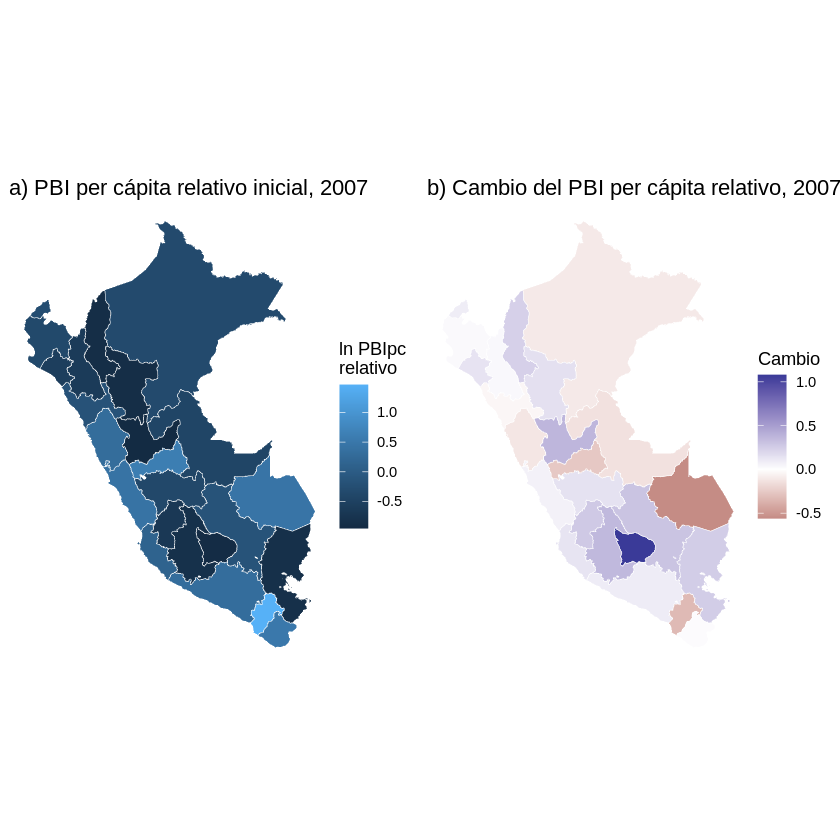

In [33]:
p_pbi_inicial <- ggplot(mapa_datos) +
  geom_sf(
    aes(fill = ln_rgdpc_2007),
    color = "white",
    linewidth = 0.15
  ) +
  scale_fill_gradient(
    name = "ln PBIpc\nrelativo"
  ) +
  labs(
    title = "a) PBI per cápita relativo inicial, 2007"
  ) +
  theme_void()

p_cambio_pbi <- ggplot(mapa_datos) +
  geom_sf(
    aes(fill = d_rgdpc),
    color = "white",
    linewidth = 0.15
  ) +
  scale_fill_gradient2(
    midpoint = 0,
    name = "Cambio"
  ) +
  labs(
    title = "b) Cambio del PBI per cápita relativo, 2007–2019"
  ) +
  theme_void()

figura_anexo_pbi <- p_pbi_inicial + p_cambio_pbi

ggsave(
  "figures/figura_A1_mapas_pbi.png",
  plot = figura_anexo_pbi,
  width = 12,
  height = 6,
  dpi = 300
)

figura_anexo_pbi

agg_record_213463427a8 
                     2

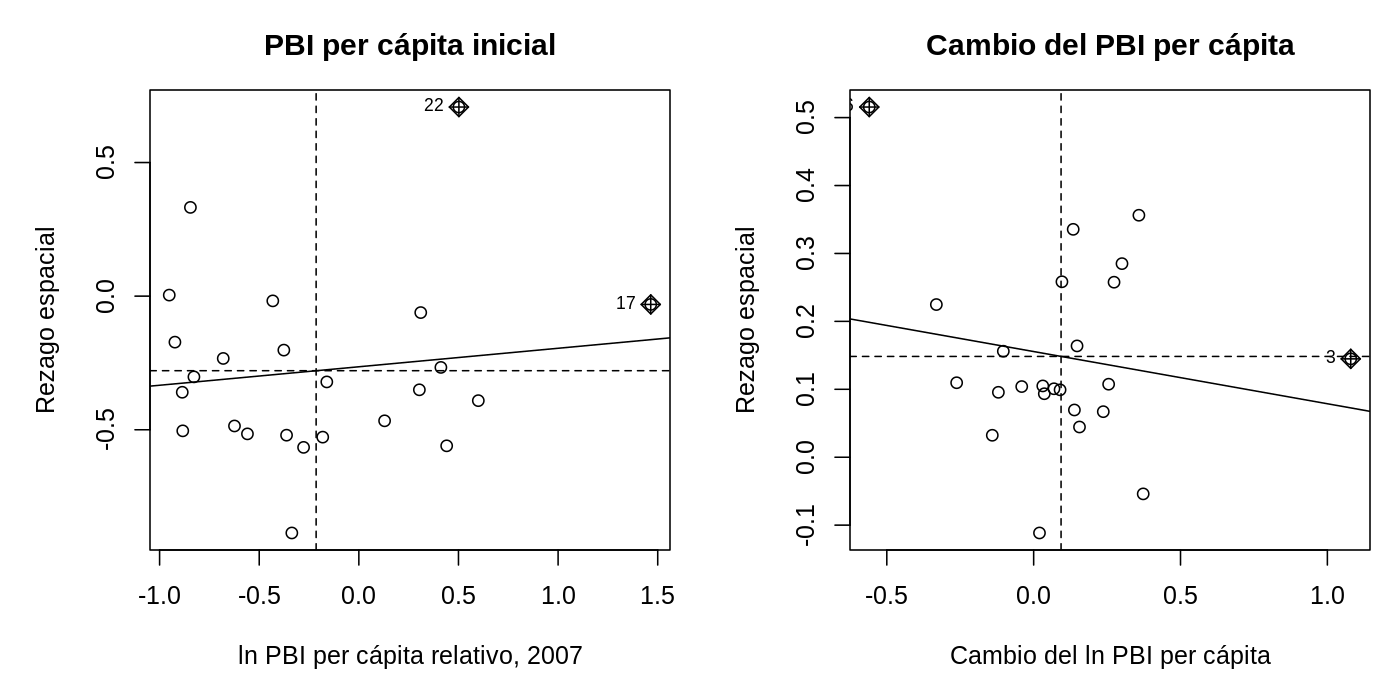

In [34]:
png(
  "figures/figura_A2_moran_pbi.png",
  width = 1400,
  height = 700,
  res = 150
)

par(
  mfrow = c(1, 2),
  mar = c(5, 5, 3, 1)
)

moran.plot(
  mapa_datos$ln_rgdpc_2007,
  W_dist,
  zero.policy = TRUE,
  xlab = "ln PBI per cápita relativo, 2007",
  ylab = "Rezago espacial",
  main = "PBI per cápita inicial"
)

moran.plot(
  mapa_datos$d_rgdpc,
  W_dist,
  zero.policy = TRUE,
  xlab = "Cambio del ln PBI per cápita",
  ylab = "Rezago espacial",
  main = "Cambio del PBI per cápita"
)

dev.off()

IRdisplay::display_png(
  file = "figures/figura_A2_moran_pbi.png"
)